# Cloud Infrastructure Telemetry Analytics & Incident Prediction System
**AICTE | IBM SkillsBuild Data Analytics with AI Academic Internship**  
**Author:** Adithya Jesuman  
**Domain:** Cloud Telemetry & Site Reliability Engineering (SRE)


In [1]:
import os
os.environ['LOKY_MAX_CPU_COUNT'] = '4'
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, IsolationForest
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
sns.set_theme(style='whitegrid', font='sans-serif')


## 1. Data Ingestion & Schema Exploration


In [2]:
df = pd.read_csv('data/cloud_telemetry_outages.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)
print('Dataset Shape:', df.shape)
print('Date Range:', df['timestamp'].min(), 'to', df['timestamp'].max())
df.head()


Dataset Shape: (4032, 11)
Date Range: 2014-02-14 14:27:00 to 2014-02-28 14:22:00


,timestamp,company_id,service_name,cpu_percent,memory_percent,response_time_ms,error_rate,active_connections,throughput_rps,queue_depth,db_query_time_ms
0,2014-02-14 14:27:00,AWS-Enterprise-Cluster,unified-cluster-service,70.0,45.0,2670.0,113239.3,182,5640,629107,34.7
1,2014-02-14 14:32:00,AWS-Enterprise-Cluster,unified-cluster-service,60.1,45.0,1720.0,1441579.5,179,3360,8008775,33.7
2,2014-02-14 14:37:00,AWS-Enterprise-Cluster,unified-cluster-service,55.7,45.0,4995.0,129328.6,181,11220,718492,34.4
3,2014-02-14 14:42:00,AWS-Enterprise-Cluster,unified-cluster-service,65.6,45.0,2695.0,107524.8,179,5700,597360,33.7
4,2014-02-14 14:47:00,AWS-Enterprise-Cluster,unified-cluster-service,63.1,45.0,1595.0,110646.0,179,3060,614700,33.8


## 2. Descriptive Telemetry Statistics


In [3]:
summary = df.describe().round(2)
summary


,timestamp,cpu_percent,memory_percent,response_time_ms,error_rate,active_connections,throughput_rps,queue_depth,db_query_time_ms
count,4032,4032.00,4032.00,4032.00,4.032000e+03,4032.00,4032.00,4.032000e+03,4032.00
mean,2014-02-21 14:24:30,54.13,45.02,1751.96,2.568644e+05,190.75,3710.22,1.427024e+06,38.45
min,2014-02-14 14:27:00,34.80,45.00,320.00,1.733250e+04,175.00,60.00,9.629100e+04,32.80
25%,2014-02-18 02:25:45,39.30,45.00,320.00,9.870378e+04,180.00,900.00,5.483542e+05,34.00
50%,2014-02-21 14:24:30,57.90,45.00,1520.00,1.054104e+05,180.00,2880.00,5.856135e+05,34.10
75%,2014-02-25 02:23:15,62.10,45.00,2545.00,1.132986e+05,185.00,5340.00,6.294368e+05,35.70
max,2014-02-28 14:22:00,91.90,81.80,16720.00,1.103067e+08,1002.00,39360.00,6.128150e+08,2133.80
std,NaN,11.15,0.78,1515.55,2.073507e+06,26.28,3399.88,1.151948e+07,48.18


## 3. Exploratory Data Analysis & Telemetry Trend Visualization


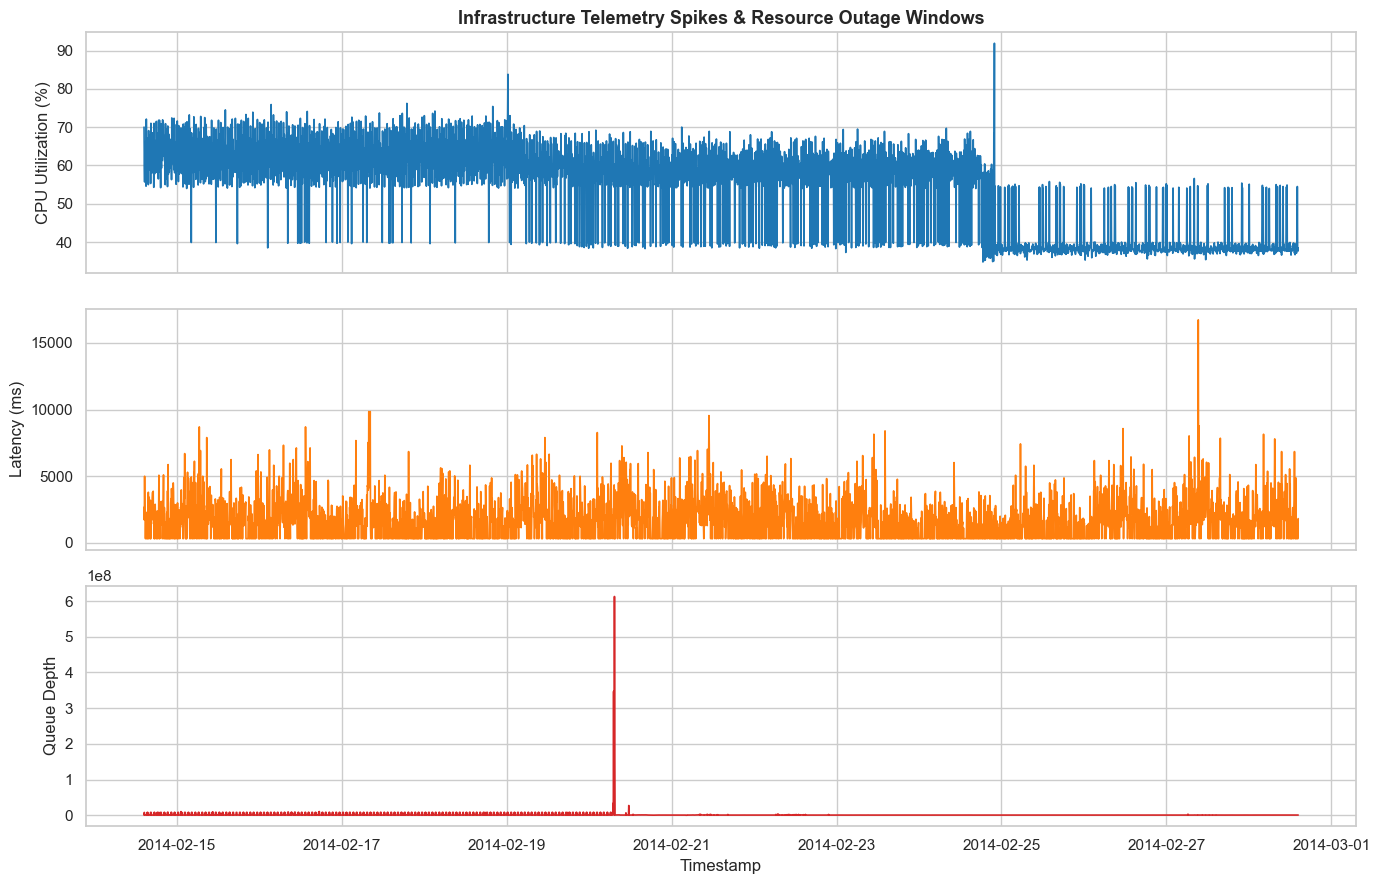

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
axes[0].plot(df['timestamp'], df['cpu_percent'], color='#1f77b4', linewidth=1.2)
axes[0].set_ylabel('CPU Utilization (%)')
axes[0].set_title('Infrastructure Telemetry Spikes & Resource Outage Windows', fontsize=13, fontweight='bold')

axes[1].plot(df['timestamp'], df['response_time_ms'], color='#ff7f0e', linewidth=1.2)
axes[1].set_ylabel('Latency (ms)')

axes[2].plot(df['timestamp'], df['queue_depth'], color='#d62728', linewidth=1.2)
axes[2].set_ylabel('Queue Depth')
axes[2].set_xlabel('Timestamp')

plt.tight_layout()
plt.show()


## 4. Correlation Analysis of Core SRE Metrics


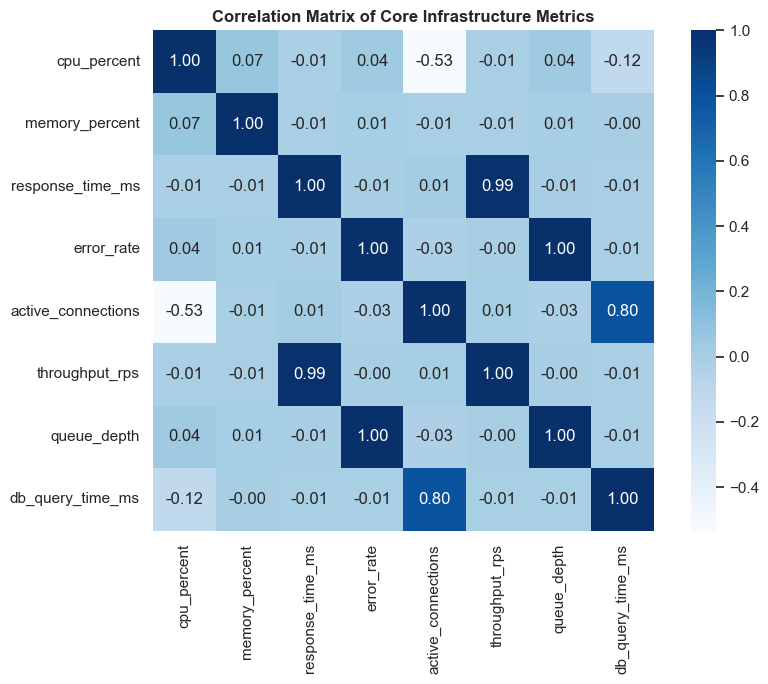

In [5]:
corr_cols = ['cpu_percent', 'memory_percent', 'response_time_ms', 'error_rate', 'active_connections', 'throughput_rps', 'queue_depth', 'db_query_time_ms']
plt.figure(figsize=(9, 7))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='Blues', square=True)
plt.title('Correlation Matrix of Core Infrastructure Metrics', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## 5. Feature Engineering & Lead-Time Label Generation


In [6]:
data = df.copy()
metrics = ['cpu_percent', 'response_time_ms', 'queue_depth', 'error_rate', 'db_query_time_ms']
for m in metrics:
    data[f'{m}_roll_mean_3'] = data[m].rolling(window=3, min_periods=1).mean()
    data[f'{m}_roll_std_3'] = data[m].rolling(window=3, min_periods=1).std().fillna(0)
    data[f'{m}_lag_1'] = data[m].shift(1).bfill()
    data[f'{m}_diff_1'] = data[m] - data[f'{m}_lag_1']

data['cpu_memory_ratio'] = data['cpu_percent'] / (data['memory_percent'] + 1e-5)
data['queue_to_throughput'] = data['queue_depth'] / (data['throughput_rps'] + 1.0)
data['latency_db_ratio'] = data['response_time_ms'] / (data['db_query_time_ms'] + 1.0)

outage_condition = (
    (data['error_rate'] > 500000.0) |
    (data['response_time_ms'] > 3000.0) |
    (data['queue_depth'] > 5000000.0)
).astype(int)

data['incident_lead'] = outage_condition.rolling(window=4, min_periods=1).max().shift(-3).fillna(0).astype(int)
print('Total Recorded Target Events:', data['incident_lead'].value_counts().to_dict())


Total Recorded Target Events: {1: 2404, 0: 1628}


## 6. Chronological Train-Test Split


In [7]:
feature_cols = [
    'cpu_percent', 'memory_percent', 'response_time_ms', 'error_rate',
    'active_connections', 'throughput_rps', 'queue_depth', 'db_query_time_ms',
    'cpu_percent_roll_mean_3', 'cpu_percent_roll_std_3', 'cpu_percent_diff_1',
    'response_time_ms_roll_mean_3', 'response_time_ms_roll_std_3', 'response_time_ms_diff_1',
    'queue_depth_roll_mean_3', 'queue_depth_diff_1',
    'error_rate_roll_mean_3', 'error_rate_diff_1',
    'cpu_memory_ratio', 'queue_to_throughput', 'latency_db_ratio'
]
target_col = 'incident_lead'

split_idx = int(len(data) * 0.8)
train_df = data.iloc[:split_idx]
test_df = data.iloc[split_idx:]

X_train = train_df[feature_cols]
y_train = train_df[target_col]
X_test = test_df[feature_cols]
y_test = test_df[target_col]

print('Training Set Size:', X_train.shape)
print('Testing Set Size:', X_test.shape)


Training Set Size: (3225, 21)
Testing Set Size: (807, 21)


## 7. Model Training & Benchmarking


In [8]:
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=2000, random_state=42))
    ]),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight='balanced'),
    'HistGradientBoosting': HistGradientBoostingClassifier(max_iter=100, max_depth=8, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else preds
    results[name] = {
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds, zero_division=0),
        'Recall': recall_score(y_test, preds, zero_division=0),
        'F1-Score': f1_score(y_test, preds, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, proba)
    }

iso = IsolationForest(contamination=0.08, random_state=42)
iso.fit(X_train)
iso_preds = (iso.predict(X_test) == -1).astype(int)
results['Isolation Forest'] = {
    'Accuracy': accuracy_score(y_test, iso_preds),
    'Precision': precision_score(y_test, iso_preds, zero_division=0),
    'Recall': recall_score(y_test, iso_preds, zero_division=0),
    'F1-Score': f1_score(y_test, iso_preds, zero_division=0),
    'ROC-AUC': roc_auc_score(y_test, iso_preds)
}

benchmark_df = pd.DataFrame(results).T.round(4)
benchmark_df


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.6828,0.8160,0.5365,0.6474,0.7570
Random Forest,0.6629,0.7293,0.6027,0.6600,0.7559
HistGradientBoosting,0.6976,0.7853,0.6096,0.6864,0.7698
Isolation Forest,0.5836,0.8110,0.3037,0.4419,0.6098


## 8. Benchmark Visualization


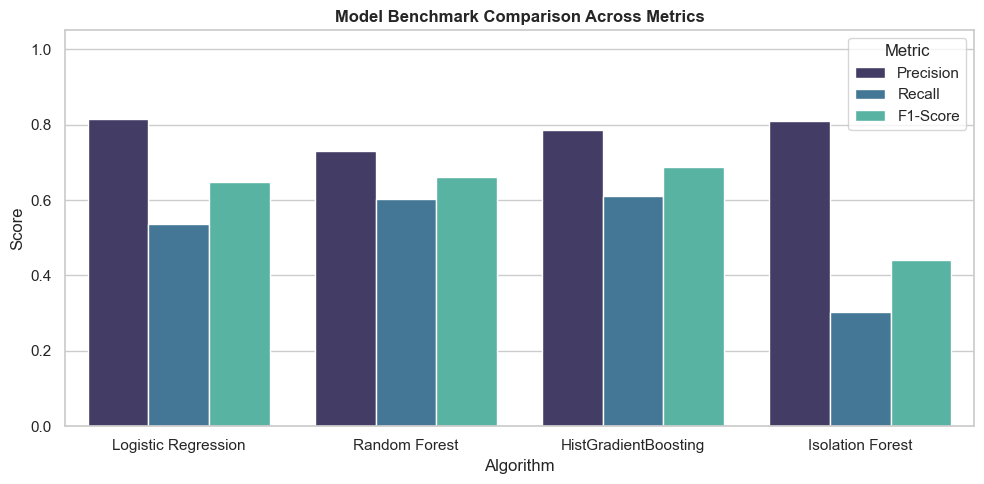

In [9]:
plt.figure(figsize=(10, 5))
plot_df = benchmark_df.reset_index().melt(id_vars='index', value_vars=['Precision', 'Recall', 'F1-Score'], var_name='Metric', value_name='Score')
sns.barplot(data=plot_df, x='index', y='Score', hue='Metric', palette='mako')
plt.title('Model Benchmark Comparison Across Metrics', fontsize=12, fontweight='bold')
plt.xlabel('Algorithm')
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()


## 9. Feature Importance Driver Analysis


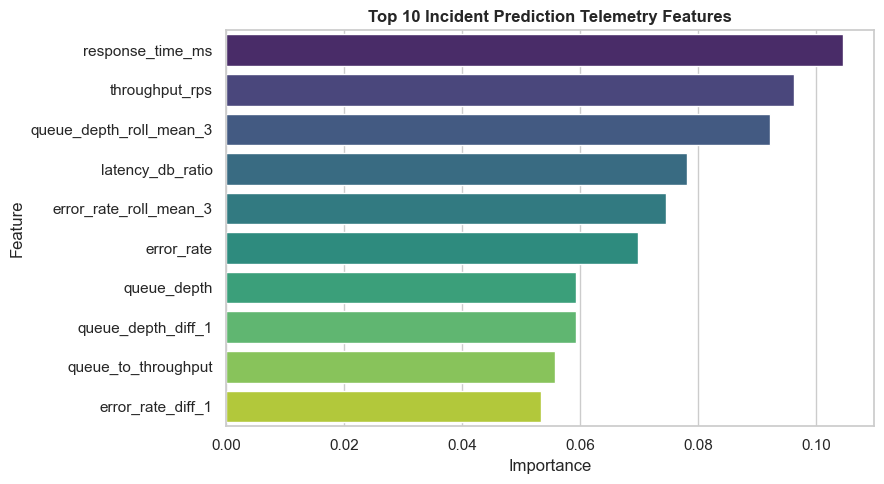

In [10]:
rf = models['Random Forest']
importances = rf.feature_importances_
fi_df = pd.DataFrame({'Feature': feature_cols, 'Importance': importances}).sort_values('Importance', ascending=False).head(10)

plt.figure(figsize=(9, 5))
sns.barplot(data=fi_df, x='Importance', y='Feature', hue='Feature', palette='viridis', legend=False)
plt.title('Top 10 Incident Prediction Telemetry Features', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## 10. Confusion Matrix & Decision Reliability Evaluation


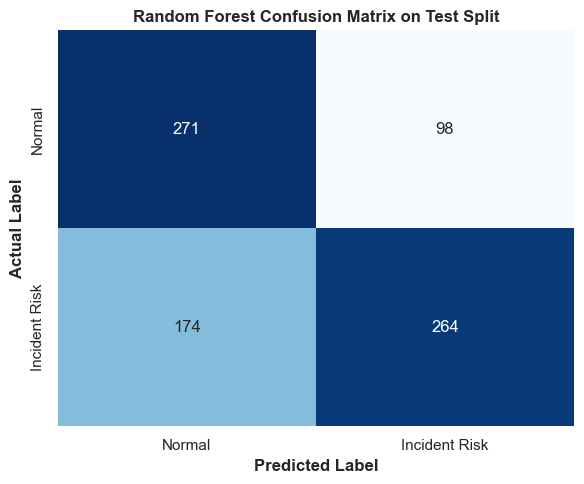

In [11]:
rf_preds = models['Random Forest'].predict(X_test)
cm = confusion_matrix(y_test, rf_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Normal', 'Incident Risk'], yticklabels=['Normal', 'Incident Risk'])
plt.xlabel('Predicted Label', fontweight='bold')
plt.ylabel('Actual Label', fontweight='bold')
plt.title('Random Forest Confusion Matrix on Test Split', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
